In [1]:
from casadi import *
import numpy as np
import matplotlib.pyplot as plt

# Model definition

In [2]:
# Define the Ruan model from (Ruan et al., 2017), (Abuin et al., 2020)

# Parameters from (Abuin et al., 2020), identified from 10 in-silico adults
# in order: endogenous glucose production, glucose effectiveness, insulin sensitivity, carbohidrate factor, time-to-maximum effective insulin concentration, time-of-maximum appearance rate of glucose in gut)
PARAMETERS = [
    [1.327, 0.0034, 44.223, 2.308, 56.001, 21.840]
]
PATIENT = 0

theta_0 = PARAMETERS[PATIENT][0]
theta_1 = PARAMETERS[PATIENT][1]
theta_2 = PARAMETERS[PATIENT][2]
theta_3 = PARAMETERS[PATIENT][3]
theta_4 = PARAMETERS[PATIENT][4]
theta_5 = PARAMETERS[PATIENT][5]

A = DM([
    [ -theta_1  , -theta_2      , 0         , theta_3   , 0],
    [ 0         , -1/theta_4    , 1/theta_4 , 0         , 0],
    [ 0         , 0             , -1/theta_4, 0         , 0],
    [ 0         , 0             , 0         , -1/theta_5, 1/theta_5],
    [ 0         , 0             , 0         , 0         , -1/theta_5],    
    ])

# input matrix of u(t) i.e. insulin infusion rate (both basal and boluses) [U/min]
Bu = DM([[0], [0], [1/theta_4], [0], [0]])
# input matrix of r(t) u.e. carbohydrate intake rate (CHO) [g/min]
Br = DM([[0], [0], [0], [0], [1/theta_4]])
# basal steady-state endogenous glucose production
E = DM([[theta_0], [0], [0], [0], [0]])
# input (Blood Glucose Levels)
C = DM([1, 0, 0, 0, 0])

# stack the two input vectors into a single input matrix since casadi integrators only allow for one control vector
B = horzcat(Bu, Br)

print(A)
print(B)
print(E)

print(C)


[[-0.0034, -44.223, 0, 2.308, 0], 
 [0, -0.0178568, 0.0178568, 0, 0], 
 [0, 0, -0.0178568, 0, 0], 
 [0, 0, 0, -0.0457875, 0.0457875], 
 [0, 0, 0, 0, -0.0457875]]

[[0, 0], 
 [0, 0], 
 [0.0178568, 0], 
 [0, 0], 
 [0, 0.0178568]]
[1.327, 0, 0, 0, 0]
[1, 0, 0, 0, 0]


# Input preparation

In [3]:
minute = 60 # [s], one minute = 60s
hour = 60*minute # [s] one hour = 60 minutes = 60*60 seconds
day = 24*hour  # [s] one day = 24 hours = 24*60 minutes = 24*60*60 seconds

te = 2*day # simulation end time (2 days)
dt = 5*minute # how often to save results of state trajectory (5min)
tout = np.linspace(0., te, te//dt)

# TEST: no meals, no basal insulin. I should observe hypoglycaemia almost immediately (IT DOES!)
u_seq = np.zeros(shape=tout.size)
r_seq = np.zeros(shape=tout.size)

print(u_seq.shape)

# helper function from time in seconds to index in the tout array
def t2idx(secs):
    return int(secs * tout.size / te)

def cho_rate(cho, secs):
    return cho/secs

# meals used for dataset collection in (Sonzogni et al., 2025)
# a meal is diluted through the period of time of the meal
r_seq[t2idx( (0*day + 7.5*hour)   ):t2idx( (0*day + 7.75*hour)   )] = cho_rate(30, 15*minute)
r_seq[t2idx( (0*day + 12*hour)   ):t2idx( (0*day + 12.25*hour)   )] = cho_rate(70, 15*minute)
r_seq[t2idx( (0*day + 20*hour)   ):t2idx( (0*day + 20.25*hour)   )] = cho_rate(80, 15*minute)

r_seq[t2idx( (1*day + 7*hour)   ):t2idx( (1*day + 7.25*hour)   )] = cho_rate(20, 15*minute)
r_seq[t2idx( (1*day + 12.5*hour)   ):t2idx( (1*day + 12.75*hour)   )] = cho_rate(50, 15*minute)
r_seq[t2idx( (1*day + 19*hour)   ):t2idx( (1*day + 19.25*hour)   )] = cho_rate(60, 15*minute)


(576,)


In [4]:
# continuous time integration with pre-programmed meals and insulin

# x = MX.sym('x', 5)
# U = MX.sym('u', 2)

# ode = {'x':x, 'u': U, 'ode': A@x + B@U + E}
# F = integrator('F','cvodes',ode, 0, tout ,opts)

# # integration only allows for one control vector U, so the u, r have to be stacked
# U_seq = horzcat(u_seq, r_seq).T

# # integrate
# res = F(x0=[100,0,0,0,0], u=U_seq)

# print(tout.size)

# x = res['xf'][0,:].T
# fig, ax = plt.subplots()
# ax.plot(tout, x)

# Discrete time simulation with PID controller

Text(0.5, 0, 't [s]')

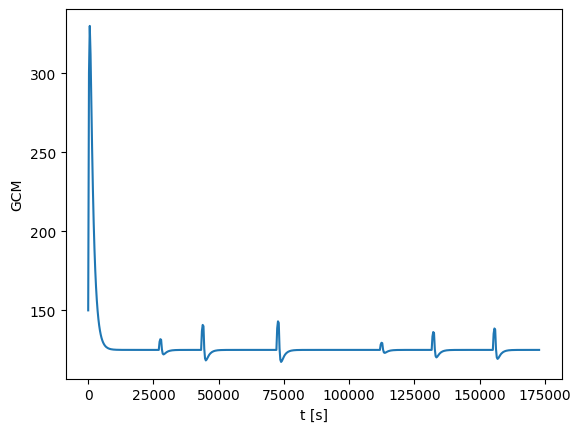

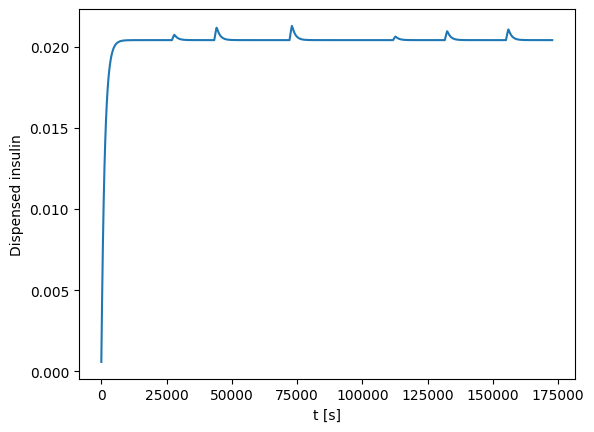

In [5]:
x = MX.sym('x', 5)
v = MX.sym('v', 2)

ode = {'x':x, 'u': v, 'ode': A@x + B@v + E}
opts = {}
 
# TODO: change this to pytorch tensors instead of later?
Y = np.zeros(shape=tout.size)
V = np.zeros(shape=tout.size)

setpoint = (180+70)//2 # half-way between hyper- and hypo- glycaemia
#print(f"Setpoint {setpoint}")
x0 = x0=[150,0,0,0,0]
ierr = 0
err_old = 0

kp=-5e-6
ki=-5e-8
kd=-1e-3

for idx,t in enumerate(range(0, te, dt)):
    Y[idx] = x0[0]

    # pid controller
    err = setpoint - x0[0]
    ierr = ierr + err*dt
    derr = (err - err_old)/dt

    #print(err, ierr, derr)

    # compute controller (ZOH)
    upid = kp*err + ki*ierr + kd*derr
    V[idx] = upid

    # simulate one dt in continous time
    F = integrator('F','cvodes',ode, t, t+dt,opts)
    # integrate
    res = F(x0=x0, u=vertcat(upid, r_seq[idx]))
    x0 = res['xf']


fig, ax = plt.subplots()
plt.plot(tout, Y)
plt.ylabel("GCM")
plt.xlabel("t [s]")
fig, ax = plt.subplots()
plt.plot(tout, V)
plt.ylabel("Dispensed insulin")
plt.xlabel("t [s]")

# Dataset preparation

LSTM layers require sequences as inputs.
Divide the data into input (insulin by controller, meals) and output sequences. Use some days for training, some for validation, some for testing.


In [18]:
import torch
from torch import nn
from torch.nn.utils.rnn import pack_sequence
from torch.utils.data import Dataset, DataLoader


# device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

torch.set_default_dtype(torch.float32)
torch.set_default_device("cpu")
torch.get_default_device()


batch_size = 2

# Two inputs: u,r
# Create packed sequences of multiple u,r
# Each sequence is obtained by sampling the dataset for 3hours. No overlap between sequences
# https://docs.pytorch.org/docs/2.12/generated/torch.nn.utils.rnn.pack_sequence.html#torch.nn.utils.rnn.pack_sequence
# https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html

class SequenceDataset(Dataset):
    def __init__(self, insulin, meals, bgls, interval_len):
        assert len(insulin) == len(meals) == len(bgls)
        
        # print(insulin.shape)
        # how many sequences
        self.interval_len = interval_len
        self.len = max(insulin.size()) // interval_len

        # print(self.len)

        self.input = torch.cat((insulin, meals), dim=0)
        self.bgls = bgls
        print(self.input)
        # pack them into sequences
        self.x = torch.split(self.input, interval_len, dim=1)
        self.y = torch.split(bgls, interval_len, dim=1)

        # print("x", len(self.x), self.x)
        # print("y", len(self.y), self.y)

                
    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        # print("idx", idx)
        sample = {'inputs': self.x[idx], 'bgl': self.y[idx]}
        return sample


# Associate each sequence with its respective output
train_dataset = SequenceDataset(torch.tensor(V, dtype=torch.float32).reshape(1, -1),
                                torch.tensor(r_seq, dtype=torch.float32).reshape(1, -1),
                                torch.tensor(Y, dtype=torch.float32).reshape(1, -1), 50)

# Dataset loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

sample = next(iter(train_loader))
print(sample)

# test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
#                                           batch_size=batch_size, 
#                                           shuffle=False)

tensor([[0.0006, 0.0045, 0.0078,  ..., 0.0204, 0.0204, 0.0204],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])
{'inputs': tensor([[[0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
          0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
          0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
          0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
          0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204, 0.0204,
          0.0204, 0.0205, 0.0206, 0.0207, 0.0207, 0.0206, 0.0206, 0.0205,
          0.0205, 0.0205],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0333, 0

# NN structure

The NN is made of two LSTM layers and two FC layers

In [38]:
class NN(nn.Module):
    def __init__(self, hidden_states):
        super(NN, self).__init__()
        # torch.manual_seed(2)

        # multiple LSTM layers
        # The first layer has two inputs (insulin, meal) and some hidden states

        # TODO: dropout, L2 regularization?
        self.lstm = nn.LSTM(2, hidden_states, batch_first=True)

        # one readout layer
        # the output is the correction to a single sampling time, so dimension 1
        self.fc = torch.nn.Linear(hidden_states, 1)    

    def forward(self, x):
        # the input is a sequence 
        out, (h_n, c_n) = self.lstm(x.T)
        r = self.fc(out)
        # TODO: detach? https://github.com/ritchieng/deep-learning-wizard/blob/master/docs/deep_learning/practical_pytorch/pytorch_lstm_neuralnetwork.md
        return r

# Training

In [39]:
# hidden states size is a hyperparameter. The real dynamics of the Ruan model has five state components
model = NN(200)
x = sample['inputs']
ym = model(sample['inputs'])
print(ym)

tensor([[[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

        [[0.0041],
         [0.0048]],

